# 6.1 — Valgbar integrasjonsmetode og konvergensplott

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson, quad, fixed_quad


def integrate(f, a, b, n=101, metode="midtpunkt"):
    if metode == "midtpunkt":
        h = (b - a) / (n - 1)
        ms = np.arange(a + 0.5*h, b, h)
        return h * np.sum(f(ms))
    elif metode == "trapes":
        xs = np.linspace(a, b, n)
        return np.trapezoid(f(xs), xs)
    elif metode == "simpson":
        n_odd = n if n % 2 == 1 else n + 1
        xs = np.linspace(a, b, n_odd)
        return simpson(f(xs), x=xs)
    elif metode == "adaptiv":
        verdi, _ = quad(f, a, b)
        return verdi
    elif metode == "gauss_legendre":
        verdi, _ = fixed_quad(f, a, b, n=n)
        return verdi
    else:
        raise ValueError(f"Ukjent metode: {metode!r}")


def legendre(n, x):
    if n == 0:
        return np.ones_like(x, dtype=float)
    elif n == 1:
        return np.asarray(x, dtype=float)
    val0, val1 = 1.0, np.asarray(x, dtype=float)
    for j in range(1, n):
        val2 = ((2*j + 1)*val1*x - j*val0) / (j + 1)
        val0, val1 = val1, val2
    return val2


def f(x):
    return np.exp(-x**2) * (x**2 - 0.5*x + 0.5)


def approksimer(n=101, grad=4, metode="midtpunkt", basis="Legendre"):
    xs_plot = np.linspace(-1, 1, 1001)
    dx = xs_plot[1] - xs_plot[0]

    if basis == "Legendre":
        a = np.zeros(grad + 1)
        for k in range(grad + 1):
            a[k] = (2*k + 1) / 2 * integrate(
                lambda x, k=k: f(x) * legendre(k, x), -1.0, 1.0, n=n, metode=metode
            )
        p = sum(a[k] * legendre(k, xs_plot) for k in range(grad + 1))
        print(f"n={n}  |  grad={grad}  |  metode='{metode}'  |  basis='Legendre'")
        for k in range(grad + 1):
            print(f"  a_{k} = {a[k]:.8f}")
        etikett = f"$p_{{{grad}}}(x)$ [Legendre, {metode}]"
        tittel  = f"Legendre  |  grad {grad}  |  {metode}  |  n={n}"
        noder   = None

    elif basis == "interpolasjon":
        j = np.arange(grad + 1)
        noder = np.sort(np.cos((2*j + 1) * np.pi / (2*(grad + 1))))
        p = np.polyval(np.polyfit(noder, f(noder), grad), xs_plot)
        a = None
        print(f"grad={grad}  |  basis='interpolasjon'  (Chebyshev-noder)")
        etikett = f"$p_{{{grad}}}(x)$ [interpolasjon, Chebyshev]"
        tittel  = f"Interpolasjon  |  grad {grad}  |  Chebyshev-noder"

    else:
        raise ValueError(f"Ukjent basis: {basis!r}")

    l2 = np.sqrt(dx * np.sum((f(xs_plot) - p)**2))
    print(f"L²-feil  ||f - p_{grad}||₂ ≈ {l2:.2e}")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(xs_plot, f(xs_plot), label="$f(x)$", linewidth=2, color="black")
    ax.plot(xs_plot, p, label=etikett, linestyle="--", linewidth=2)
    if noder is not None:
        ax.scatter(noder, f(noder), zorder=5, label="interpolasjonsnoder", color="tab:red")
    ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
    ax.set_title(f"{tittel}\n$L^2$-feil ≈ {l2:.1e}")
    ax.legend(); ax.grid(); plt.tight_layout(); plt.show()

    return a, p, l2


## Konfigurer og kjør

Bytt variablene nedenfor og kjør cellen på nytt:

| Variabel | Valg |
|----------|------|
| `N` | antall noder for integrasjon |
| `GRAD` | polynomdgrad 0–4 |
| `METODE` | `"midtpunkt"` · `"trapes"` · `"simpson"` · `"adaptiv"` · `"gauss_legendre"` |
| `BASIS` | `"Legendre"` · `"interpolasjon"` |


n=1000  |  grad=5  |  metode='midtpunkt'  |  basis='Legendre'
  a_0 = 0.56288447
  a_1 = -0.28420852
  a_2 = 0.05532518
  a_3 = 0.11737891
  a_4 = -0.08006534
  a_5 = -0.01883458
L²-feil  ||f - p_5||₂ ≈ 6.04e-03


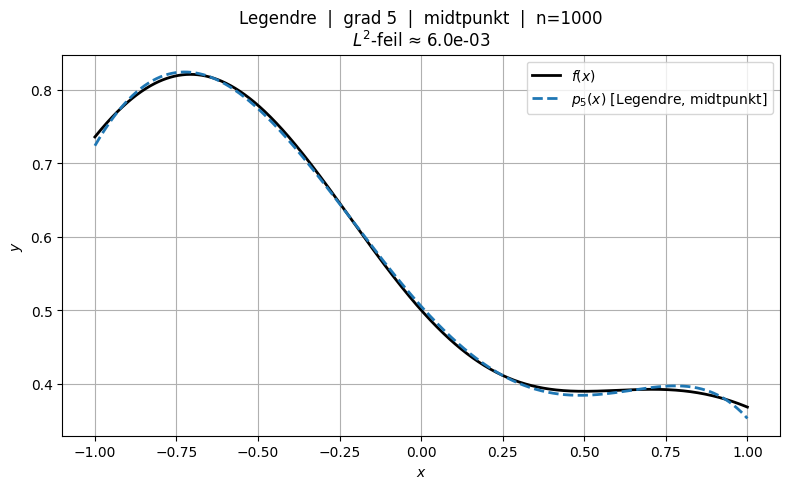

In [9]:
# --- Konfigurer her ---
N      = 1000              # antall noder  (delintervaller = N-1)
GRAD   = 5                # polynomdgrad  (vilkårlig ikke-negativ heltall)
METODE = "midtpunkt"      # prøv: "midtpunkt", "trapes", "simpson", "adaptiv", "gauss_legendre"
BASIS  = "Legendre"       # prøv: "Legendre", "interpolasjon"

a, p4, l2 = approksimer(N, GRAD, METODE, BASIS)


## Konvergensplott — $p_M(x)$ for $M = 0, 1, 2, 3, 4$

Fordi $P_k$ er ortogonale bestemmes hver $a_k$ uavhengig — de endres ikke når vi legger til eller fjerner ledd.

L²-feil per grad:
  M = 0:  ||f - p_0||₂ ≈ 2.46e-01
  M = 1:  ||f - p_1||₂ ≈ 8.19e-02
  M = 2:  ||f - p_2||₂ ≈ 7.41e-02
  M = 3:  ||f - p_3||₂ ≈ 3.92e-02
  M = 4:  ||f - p_4||₂ ≈ 1.01e-02


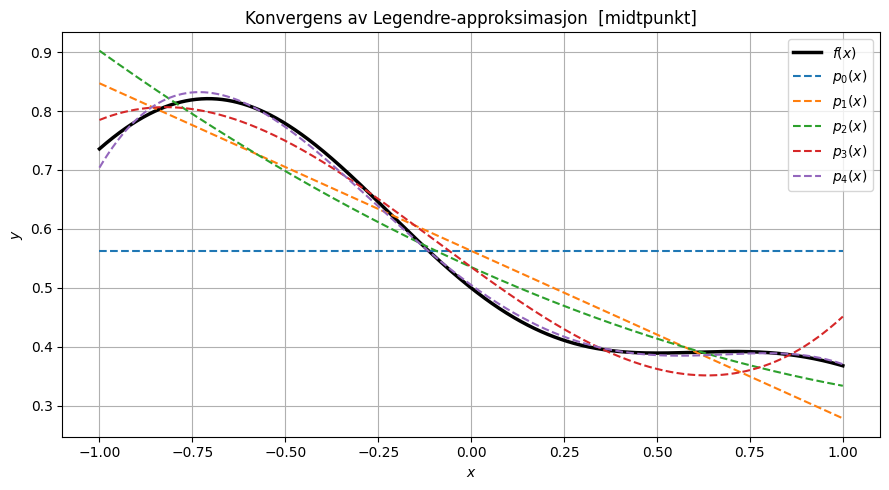

In [3]:
xs = np.linspace(-1, 1, 1001)
dx = xs[1] - xs[0]

# Beregn a_0...a_4 med valgt metode (alltid grad 4 for sammenligning)
a_full = np.zeros(5)
for k in range(5):
    a_full[k] = (2*k + 1) / 2 * integrate(
        lambda x, k=k: f(x) * legendre(k, x), -1.0, 1.0, n=N, metode=METODE
    )

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xs, f(xs), color="black", linewidth=2.5, label="$f(x)$")

print("L²-feil per grad:")
for M in range(5):
    p_M = sum(a_full[k] * legendre(k, xs) for k in range(M + 1))
    l2 = np.sqrt(dx * np.sum((f(xs) - p_M)**2))
    print(f"  M = {M}:  ||f - p_{M}||₂ ≈ {l2:.2e}")
    ax.plot(xs, p_M, linestyle="--", linewidth=1.5, label=f"$p_{M}(x)$")

ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
ax.set_title(f"Konvergens av Legendre-approksimasjon  [{METODE}]")
ax.legend(loc="upper right"); ax.grid(); plt.tight_layout(); plt.show()
